In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/jerusonj/cifar10-by-jerry/cifar-10-python/cifar-10-batches-py/data_batch_1
/kaggle/input/datasets/jerusonj/cifar10-by-jerry/cifar-10-python/cifar-10-batches-py/data_batch_2
/kaggle/input/datasets/jerusonj/cifar10-by-jerry/cifar-10-python/cifar-10-batches-py/batches.meta
/kaggle/input/datasets/jerusonj/cifar10-by-jerry/cifar-10-python/cifar-10-batches-py/test_batch
/kaggle/input/datasets/jerusonj/cifar10-by-jerry/cifar-10-python/cifar-10-batches-py/data_batch_3
/kaggle/input/datasets/jerusonj/cifar10-by-jerry/cifar-10-python/cifar-10-batches-py/data_batch_5
/kaggle/input/datasets/jerusonj/cifar10-by-jerry/cifar-10-python/cifar-10-batches-py/data_batch_4
/kaggle/input/datasets/jerusonj/cifar10-by-jerry/cifar-10-python/cifar-10-batches-py/readme.html


In [2]:
import torch
import numpy as np

print(f"PyTorch Version: {torch.__version__}")

# 1. The Divine Fire: Checking if the GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")

print("\n--- NumPy vs PyTorch Practice ---")

# 2. Creating a 2D array in NumPy (something you know)
np_array = np.array([[1.0, 2.0], [3.0, 4.0]])




















print(f"NumPy Array:\n{np_array} (Type: {type(np_array)})")

# 3. Forging a PyTorch Tensor from that NumPy array
py_tensor = torch.from_numpy(np_array)
print(f"PyTorch Tensor:\n{py_tensor} (Type: {type(py_tensor)})")

# 4. Sending your tensor to the GPU warrior
if torch.cuda.is_available():
    gpu_tensor = py_tensor.to(device)
    print(f"\nTensor successfully sent to GPU! Device property: {gpu_tensor.device}")

PyTorch Version: 2.10.0+cu128
Using device: cuda
GPU Model: Tesla T4

--- NumPy vs PyTorch Practice ---
NumPy Array:
[[1. 2.]
 [3. 4.]] (Type: <class 'numpy.ndarray'>)
PyTorch Tensor:
tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64) (Type: <class 'torch.Tensor'>)

Tensor successfully sent to GPU! Device property: cuda:0


In [3]:
import torch
import torch.nn as nn

class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()#initializing the parent class(nn.Module)
        
        # 1st convolution layer(shrinks dimension if stride<1)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)#we over writte and save memory
        
        #2nd convolutionlayer(maintains dimension)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # shortcut connection
        self.shortcut = nn.Sequential()
        # when dimension mismatch,we use a 1x1 layer 
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )#executes the tasks sequentially

    def forward(self, x):
        #
        identity = self.shortcut(x)

        # Route the input through the main convolutional path
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # addition
        out += identity
        out = self.relu(out)
        
        return out

In [4]:
class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_channels = 16

        # formatting the images( has 3 colour channels r-g-b)
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu = nn.ReLU(inplace=True)

        #3 stages with increasing channel depth at each stage
        self.stage1 = self.make_stages(block, 16, num_blocks[0], stride=1)
        self.stage2 = self.make_stages(block, 32, num_blocks[1], stride=2)
        self.stage3 = self.make_stages(block, 64, num_blocks[2], stride=2)

        #global average pooling and final linear classifier
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

    def make_stages(self, block, out_channels, num_blocks, stride):
        #first block in a stage handles the downsampling if stride > 1
        strides = [stride] + [1] * (num_blocks - 1)#stride is greater than 1 only in first block ,1 for all others to prevent further shrinking
        layers = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels  # next block
            
        return nn.Sequential(*layers)

    def forward(self, x):
        # Stem
        x = self.relu(self.bn1(self.conv1(x)))
        
        # Stages
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        
        # Head
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model1 = ResNet(BasicBlock,[2,2,2]).to(device)
print(model1)

ResNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (stage1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1

mean-r-g-b 0.49139968 0.48215827 0.44653124
sd-r-g-b 0.24703223 0.24348514 0.26158786
total no of training images: 50000
total no of testing images: 10000
number of training batches with 64 image per batch: 782


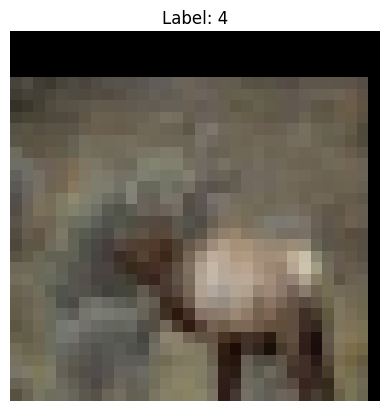

In [5]:
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plot
#it is dead slow to download the dataset from the torchvision link or the official university of toranto link
#after eons of searching i found this out

dataset_path = '/kaggle/input/datasets/jerusonj/cifar10-by-jerry/cifar-10-python'


#1. extracting the mean and std of the CIFAR-10 dataset
cifar_trainset = torchvision.datasets.CIFAR10(root=dataset_path, train=True, download=False, transform=transforms.ToTensor())

imgs = [item[0] for item in cifar_trainset] # item[0] and item[1] are image and its label
imgs = torch.stack(imgs, dim=0).numpy()

# calculate mean over each channel (r,g,b)
mean_r = imgs[:,0,:,:].mean()
mean_g = imgs[:,1,:,:].mean()
mean_b = imgs[:,2,:,:].mean()
print("mean-r-g-b",mean_r,mean_g,mean_b)

# calculate std over each channel (r,g,b)
sd_r = imgs[:,0,:,:].std()
sd_g = imgs[:,1,:,:].std()
sd_b = imgs[:,2,:,:].std()
print("sd-r-g-b",sd_r,sd_g,sd_b)
#https://stackoverflow.com/questions/66678052/how-to-calculate-the-mean-and-the-std-of-cifar10-data
#they represent the global average pixel intensity and the spread of those intensities across the entire dataset when scaled to a [0, 1] range.



# 2. formatting the data and transforming it so that images can be fed in as data (Transforms)
# Neural networks prefer numbers clustered around 0 rather than large ranges (0-255 pixels).
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(), # first step,converts the images to tensors(each pixel is now between 0 and 1)
    transforms.Normalize((mean_r,mean_g,mean_b), (sd_r,sd_g,sd_b)) # second step ,normalises(centres the data) 
])#(each pixel is now between -1 and 1),(x-mean)/sd,z-score
#without compose we have to manually apply this to every image.

test_transform = transforms.Compose([
    transforms.ToTensor(), # first step,converts the images to tensors(each pixel is now between 0 and 1)
    transforms.Normalize((mean_r,mean_g,mean_b), (sd_r,sd_g,sd_b)) # second step ,normalises(centres the data) 
])

# 2.downloading and seperating the training and testing CIFAR10 data
# train=True gets the training set, train=False gets the test set
train_set = torchvision.datasets.CIFAR10(root=dataset_path, train=True, download=False, transform=train_transform)#root=data saves the images in the folder called data in the kaagle notebook
test_set = torchvision.datasets.CIFAR10(root=dataset_path, train=False, download=False, transform=test_transform)#from step 1,we bring in the transform


# 3. batching, as the loading the gpu with all the data at once reduces the effiency,gpu sits idle for most of the time.can lead to crashes.
# We feed the network 64 images at a time instead of all 60,000 at once to save memory and improve effiency.
train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)#we shuffle the data to remove biases towards an one value,batch size is 64,at once 64 4d tensors are sent to the gpu
test_loader = torch.utils.data.DataLoader(test_set, batch_size=64, shuffle=False)#no shuffling for testing 

print(f"total no of training images: {len(train_set)}")
print(f"total no of testing images: {len(test_set)}")
print(f"number of training batches with 64 image per batch: {len(train_loader)}")

# 4. visualizing a single batch
dataiter = iter(train_loader)#we made an iterable object ,we don't need to display all images so we didn;t use for loop
images, labels = next(dataiter)#we pushed the first object up
cifar_mean=(mean_r,mean_g,mean_b)
cifar_sd=(sd_r,sd_g,sd_b)
first_image = images[0].clone()

# Un-normalize each of the 3 color channels
for i in range(3): 
    first_image[i] = first_image[i] * cifar_sd[i] + cifar_mean[i]


img_numpy = np.transpose(first_image.numpy(), (1, 2, 0))


#The PyTorch Standard (C, H, W): PyTorch stores image tensors as (Channels, Height, Width). For a CIFAR-10 image, this shape is (3, 32, 32). PyTorch puts the color channels first because it makes GPU hardware much faster at calculating convolutions.

# The Matplotlib Standard (H, W, C): Matplotlib (and standard image formats like PNG or JPEG) expects images as (Height, Width, Channels). For CIFAR-10, this is (32, 32, 3). It expects the color channels last, pairing the Red, Green, and Blue values together for every individual pixel.
#we use transpose to overcome this(tensor to matplotlib compaitable format)

# Clip pixel values back to [0, 1] range to avoid matplotlib rendering bugs
img_numpy = np.clip(img_numpy, 0, 1)

plot.imshow(img_numpy)
plot.title(f"Label: {labels[0].item()}")
plot.axis('off')
plot.show()

--- Beginning of Training (Training the model) ---
  [Epoch 1, Batch 300] Loss: 1.671
  [Epoch 1, Batch 600] Loss: 1.332
Epoch [1/50] | Train Loss: 1.4276, Train Acc: 47.26% | Val Loss: 1.2716, Val Acc: 54.79%
  [Epoch 2, Batch 300] Loss: 1.082
  [Epoch 2, Batch 600] Loss: 1.016
Epoch [2/50] | Train Loss: 1.0266, Train Acc: 63.01% | Val Loss: 0.9775, Val Acc: 65.33%
  [Epoch 3, Batch 300] Loss: 0.899
  [Epoch 3, Batch 600] Loss: 0.851
Epoch [3/50] | Train Loss: 0.8593, Train Acc: 69.30% | Val Loss: 0.8577, Val Acc: 70.24%
  [Epoch 4, Batch 300] Loss: 0.776
  [Epoch 4, Batch 600] Loss: 0.753
Epoch [4/50] | Train Loss: 0.7533, Train Acc: 73.65% | Val Loss: 0.8082, Val Acc: 72.23%
  [Epoch 5, Batch 300] Loss: 0.696
  [Epoch 5, Batch 600] Loss: 0.686
Epoch [5/50] | Train Loss: 0.6859, Train Acc: 76.06% | Val Loss: 0.6891, Val Acc: 76.11%
  [Epoch 6, Batch 300] Loss: 0.646
  [Epoch 6, Batch 600] Loss: 0.631
Epoch [6/50] | Train Loss: 0.6332, Train Acc: 77.91% | Val Loss: 0.6028, Val Acc: 79

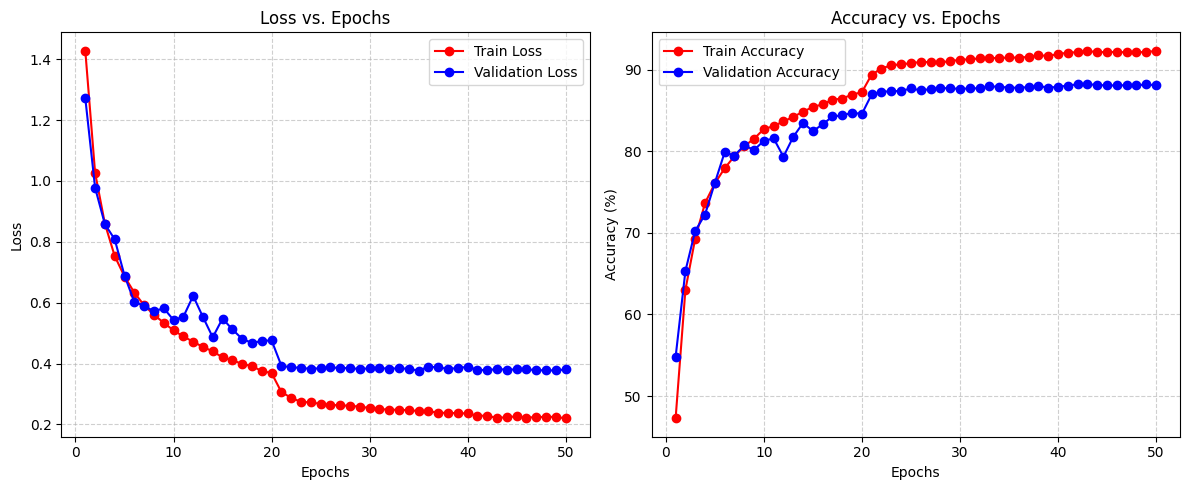

In [6]:
#  Baseline Training
import torch.optim as optim
loss_history=[]
train_acc_history = []
val_loss_history = []
val_acc_history = []
batch_loss_history=[]

# 1. The Strategy: Loss Function and Optimizer
# CrossEntropyLoss is standard for multi-class classification (digits 0-9)
criterion = nn.CrossEntropyLoss()#softmax(e^x by summation e^x)+negative-log-likelihood
#loss=- summation(ytrue*log(pmodel)),,,loss=-log(pcorrect)

# Adam is a highly efficient optimizer that dynamically adjusts the learning rate
optimizer = optim.Adam(model1.parameters(), lr=0.001)#lr=learning rate
# This multiplies the learning rate by 0.1 every 20 epochs
# (e.g., at epoch 20, lr becomes 0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)

# 2.Training Loop

#An Epoch is one complete pass through the entire library of 60,000 images,we run it 3 times because looking at the data just once isn't enough to memorize the complex patterns
epochs=50
print("--- Beginning of Training (Training the model) ---")
for epoch in range(epochs):
    model1.train() # Set the model to training mode
    running_loss = 0.0
    correct_train=0
    total_train=0
    running_batch_loss=0.0
    
    for i, (inputs, labels) in enumerate(train_loader):#batch numbers,images,answers
        # Moving the batched data to  GPU
        inputs, labels = inputs.to(device), labels.to(device)

        # Step 1: Clear the old gradients from the last step
        optimizer.zero_grad()

        # Step 2: forward pass (make blind guess)
        outputs = model1(inputs)
        
        # Step 3: Calculate the loss (How wrong was the prediction?)
        loss = criterion(outputs, labels)

        # Step 4: Backward Pass (Calculate the gradients),backpropagation
        loss.backward()

        # Step 5: Optimize (Update the models weights)
        optimizer.step()

        running_loss += loss.item()
        running_batch_loss += loss.item()
        if i % 300 == 299:
            print(f"  [Epoch {epoch + 1}, Batch {i + 1}] Loss: {running_batch_loss / 300:.3f}")
            batch_loss_history.append(running_batch_loss / 300)
            running_batch_loss = 0.0

        # calculating training accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    # calculating average loss and accuracy for the epoch
    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct_train / total_train
    
    loss_history.append(epoch_train_loss)
    train_acc_history.append(epoch_train_acc)


# --- VALIDATION PHASE ---
    model1.eval() # Set model to evaluation mode 
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    # torch.no_grad() disables gradient calculation to save memory and compute
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model1(inputs)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item()
            
            # Calculate Validation Accuracy
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    epoch_val_loss = running_val_loss / len(test_loader)
    epoch_val_acc = 100 * correct_val / total_val
    
    val_loss_history.append(epoch_val_loss)
    val_acc_history.append(epoch_val_acc)
    scheduler.step()
    
    # Print metrics for the epoch
    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")

            

print("--- Training Completed ---")

# 3. Plotting Results against Epochs
epochs_range = range(1, epochs + 1)

# Plot Loss
plot.figure(figsize=(12, 5))
plot.subplot(1, 2, 1)
plot.plot(epochs_range, loss_history, label='Train Loss', color='red', marker='o')
plot.plot(epochs_range, val_loss_history, label='Validation Loss', color='blue', marker='o')
plot.title('Loss vs. Epochs')
plot.xlabel('Epochs')
plot.ylabel('Loss')
plot.legend()
plot.grid(True, linestyle='--', alpha=0.6)

# Plot Accuracy
plot.subplot(1, 2, 2)
plot.plot(epochs_range, train_acc_history, label='Train Accuracy', color='red', marker='o')
plot.plot(epochs_range, val_acc_history, label='Validation Accuracy', color='blue', marker='o')
plot.title('Accuracy vs. Epochs')
plot.xlabel('Epochs')
plot.ylabel('Accuracy (%)')
plot.legend()
plot.grid(True, linestyle='--', alpha=0.6)

plot.tight_layout()
plot.show()

In [7]:
torch.save(model1.state_dict(), '/kaggle/working/Resnet_weights.pth')
print("Model weights saved successfully to /kaggle/working/Resnet_weights.pth!")

Model weights saved successfully to /kaggle/working/Resnet_weights.pth!



--- Classification Report ---
              precision    recall  f1-score   support

       plane       0.90      0.88      0.89      1000
         car       0.95      0.95      0.95      1000
        bird       0.81      0.84      0.83      1000
         cat       0.78      0.76      0.77      1000
        deer       0.85      0.89      0.87      1000
         dog       0.85      0.80      0.82      1000
        frog       0.90      0.91      0.91      1000
       horse       0.92      0.91      0.91      1000
        ship       0.92      0.94      0.93      1000
       truck       0.93      0.93      0.93      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



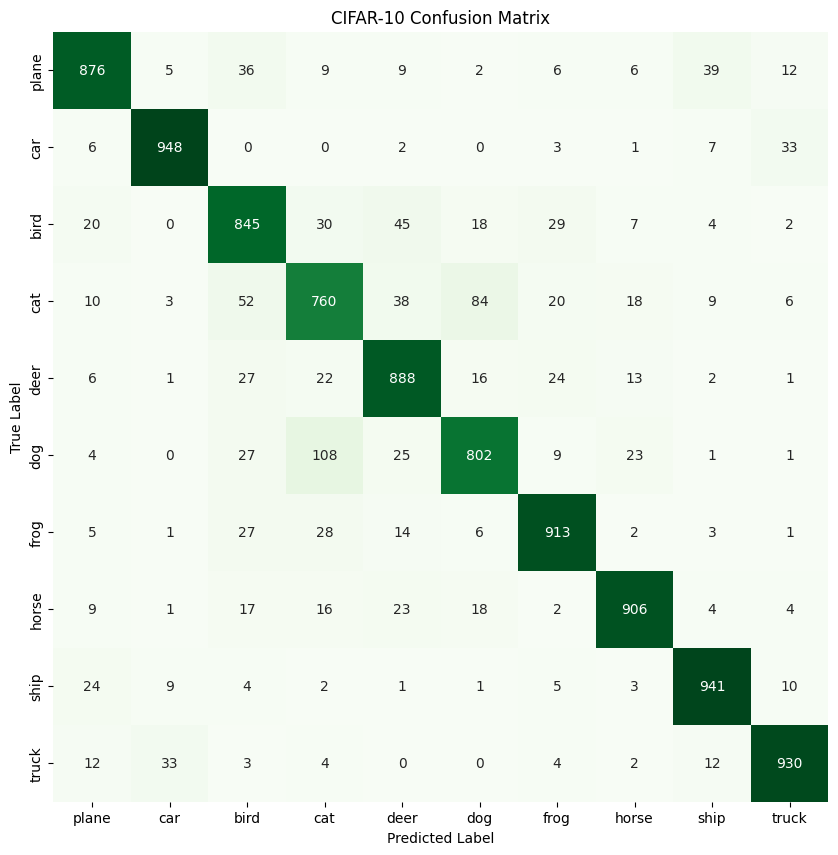

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import pandas as pd

model1.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model1(inputs)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

#all 10 class names
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

#classification report
print("\n--- Classification Report ---")
print(classification_report(all_targets, all_preds, target_names=classes))

#confusion matrix
cm = confusion_matrix(all_targets, all_preds)
plot.figure(figsize=(10,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes,cbar=False)
plot.title('CIFAR-10 Confusion Matrix')
plot.xlabel('Predicted Label')
plot.ylabel('True Label')
plot.show()